# Anomaly Detection Example

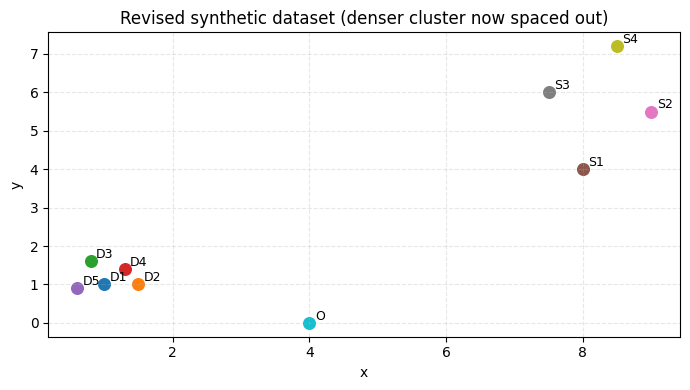

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from math import sqrt

# ------------------------------------------------------------------------------
# Regenerate the toy dataset with a *slightly wider* dense cluster
# ------------------------------------------------------------------------------

coords = {
    # dense (but now visually clearer) green-ish cluster
    "D1": (1.00, 1.00),
    "D2": (1.50, 1.00),
    "D3": (0.80, 1.60),
    "D4": (1.30, 1.40),
    "D5": (0.60, 0.90),
    # sparse red-ish cluster
    "S1": (8.00, 4.00),
    "S2": (9.00, 5.50),
    "S3": (7.50, 6.00),
    "S4": (8.50, 7.20),
    # single green outlier
    "O" : (4.00, 0.00),
}

coord_df = pd.DataFrame(coords).T.rename(columns={0: "x", 1: "y"})
coord_df.index.name = "point"

# ------------------------------------------------------------------------------
# Pair-wise Euclidean distances
# ------------------------------------------------------------------------------
labels = coord_df.index.tolist()
n = len(labels)
dist_matrix = np.zeros((n, n))

for i, j in combinations(range(n), 2):
    xi, yi = coord_df.iloc[i]
    xj, yj = coord_df.iloc[j]
    d = sqrt((xi - xj)**2 + (yi - yj)**2)
    dist_matrix[i, j] = dist_matrix[j, i] = d

dist_df = pd.DataFrame(dist_matrix, index=labels, columns=labels)

# ------------------------------------------------------------------------------
# Density & relative density (k=2)
# ------------------------------------------------------------------------------
k = 2
densities = {}
second_nn = {}

for p in labels:
    dists = dist_df.loc[p].drop(p).sort_values()
    d_k = dists.iloc[k - 1]
    second_nn[p] = d_k
    densities[p] = 1.0 / d_k

rel_density = {}
for p in labels:
    nn = dist_df.loc[p].drop(p).sort_values().index[:k]
    avg_nn_density = np.mean([densities[q] for q in nn])
    rel_density[p] = avg_nn_density / densities[p]

density_df = pd.DataFrame({
    "2nd-NN dist": pd.Series(second_nn),
    "density": pd.Series(densities),
    "rel_density (k=2)": pd.Series(rel_density)
})

# ------------------------------------------------------------------------------
# Plot for visual clarity
# ------------------------------------------------------------------------------
plt.figure(figsize=(7, 4))
for idx, (x, y) in coord_df.iterrows():
    plt.scatter(x, y, s=70)
    plt.text(x + 0.08, y + 0.08, idx, fontsize=9)
plt.title("Revised synthetic dataset (denser cluster now spaced out)")
plt.xlabel("x"); plt.ylabel("y")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()




In [ ]:
from math import sqrt

labels = coord_df.index
n = len(labels)

proximity_matrix = pd.DataFrame(0.0, index=labels, columns=labels)

for i in range(n):
	x_i, y_i = coord_df.iloc[i]
	for j in range(n):
		if i != j:
			x_j, y_j = coord_df.iloc[j]
			dist = sqrt((x_i - x_j)**2 + (y_i - y_j)**2)
			proximity_matrix.iloc[i, j] = dist

proximity_matrix.round(3)

point,D1,D2,D3,D4,D5,S1,S2,S3,S4,O
point,,,,,,,,,,
D1,0.000,0.500,0.632,0.500,0.412,7.616,9.179,8.201,9.731,3.162
D2,0.500,0.000,0.922,0.447,0.906,7.159,8.746,7.810,9.351,2.693
D3,0.632,0.922,0.000,0.539,0.728,7.589,9.080,8.016,9.521,3.578
D4,0.500,0.447,0.539,0.000,0.860,7.187,8.724,7.720,9.246,3.041
D5,0.412,0.906,0.728,0.860,0.000,8.023,9.577,8.580,10.104,3.517
S1,7.616,7.159,7.589,7.187,8.023,0.000,1.803,2.062,3.239,5.657
S2,9.179,8.746,9.080,8.724,9.577,1.803,0.000,1.581,1.772,7.433
S3,8.201,7.810,8.016,7.720,8.580,2.062,1.581,0.000,1.562,6.946
S4,9.731,9.351,9.521,9.246,10.104,3.239,1.772,1.562,0.000,8.491


In [ ]:
density_df

,2nd-NN dist,density,rel_density (k=2)
D1,0.500000,2.000000,0.843401
D2,0.500000,2.000000,1.000000
D3,0.632456,1.581139,1.264911
D4,0.500000,2.000000,1.000000
D5,0.728011,1.373606,1.303554
S1,2.061553,0.485071,1.233621
S2,1.772005,0.564333,1.060357
S3,1.581139,0.632456,0.892288
S4,1.772005,0.564333,1.060357
O,3.041381,0.328798,6.082763


# Housing-Price Prediction Case Study

https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12, 10)
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error as mse


from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score


import pandas as pd
from sklearn.impute import SimpleImputer as Imputer
from random import choices
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.base import BaseEstimator


In [2]:
!gdown 1F9aD344ifJiKzRDlR4ZX0e4plDuP9-b9



Downloading...
From: https://drive.google.com/uc?id=1F9aD344ifJiKzRDlR4ZX0e4plDuP9-b9
To: /content/kaggle_houseprices_modified.csv
100% 459k/459k [00:00<00:00, 91.8MB/s]


In [3]:
pd.options.display.max_columns = 500
pd.options.display.max_rows = 500

In [4]:
ds = pd.read_csv('/content/kaggle_houseprices_modified.csv')
ds.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,198075.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,199650.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,212325.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,237500.0


In [5]:
ds.shape

(1460, 81)

In [7]:
ds['ExterQual'].value_counts()

,count
ExterQual,
TA,906
Gd,488
Ex,52
Fa,14


In [8]:
todrop = ['Id']

categorical = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
               'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'RoofStyle', 'RoofMatl', 'HouseStyle',
               'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir',
               'Electrical', 'GarageType', 'PavedDrive', 'Fence', 'MiscFeature', 'MoSold', 'SaleType', 'SaleCondition']

continuous = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1',
              'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'MasVnrArea',
              'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
              'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
              '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'YrSold', 'SalePrice']


cat_to_con = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
              'HeatingQC', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond',
              'PoolQC', ]

In [9]:
ds['Electrical'].value_counts()

,count
Electrical,
SBrkr,1334
FuseA,94
FuseF,27
FuseP,3
Mix,1


In [10]:
ds['PoolQC'].value_counts()

,count
PoolQC,
Gd,3
Ex,2
Fa,2


We'll decide by:
1. Discussion with manager, PMs.
2. Try multiple permutation.

In [12]:
def pre_processing(ds, todrop, categorical, cat_to_con):


  ds = ds.drop(columns=todrop)

  logical_nans = ['Alley', 'Fence', 'MiscFeature', 'MasVnrType', 'GarageType', 'FireplaceQu', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                  'BsmtFinType2', 'GarageFinish', 'GarageQual', 'GarageCond']
  for col in logical_nans:
    ds[col] = ds[col].fillna('NA')


  ds['Electrical'] = ds['Electrical'].fillna(ds['Electrical'].value_counts().index[0])

  ds.drop(columns = ['PoolQC'], inplace=True)
  cat_to_con.remove('PoolQC')


  print("no. of nans in cat_to_con cols:",ds[cat_to_con].isna().sum().sum())

      #target_encoding
  target = 'SalePrice'
  for col in categorical:
      ds[col] = ds.groupby([col])[target].transform('mean')


    #label encoding
  grp1 = ['GarageQual', 'GarageCond', 'FireplaceQu', 'KitchenQual', 'HeatingQC', 'BsmtCond', 'BsmtQual', 'ExterCond', 'ExterQual']
  for col in grp1:
      ds[col] = ds[col].map({'TA': 3, 'Fa': 2, 'NA': 0, 'Gd': 4, 'Po': 1, 'Ex': 5})

  for col in ['BsmtFinType1', 'BsmtFinType2']:
      ds[col] = ds[col].map({'GLQ':6, 'ALQ':5, 'Unf':1, 'Rec':3, 'BLQ':4, 'NA':0, 'LwQ':2})

  ds['BsmtExposure'] = ds['BsmtExposure'].map({'No':1, 'Gd':4, 'Mn':2, 'Av':3, 'NA':0})
  ds['Functional'] = ds['Functional'].map({'Typ':7, 'Min1':6, 'Maj1':3, 'Min2':5, 'Mod':4, 'Maj2':2, 'Sev':1, 'Sal':0})
  ds['GarageFinish'] = ds['GarageFinish'].map({'RFn':2, 'Unf':1, 'Fin':3, 'NA':0})

  print("total nans in the dataframe:", ds.isna().sum().sum())

  return ds



In [13]:
ds = pre_processing(ds, todrop, categorical, cat_to_con)


no. of nans in cat_to_con cols: 0
total nans in the dataframe: 348


In [14]:
ds.isna().sum()/ds.shape[0]

,0
MSSubClass,0.000000
MSZoning,0.000000
LotFrontage,0.177397
LotArea,0.000000
Street,0.000000
Alley,0.000000
LotShape,0.000000
LandContour,0.000000
Utilities,0.000000
LotConfig,0.000000


In [15]:
ds['LotFrontage'] = ds['LotFrontage'].fillna(ds['LotFrontage'].median())
ds['MasVnrArea']  = ds['MasVnrArea'].fillna(ds['MasVnrArea'].median())
ds['GarageYrBlt'] = ds['GarageYrBlt'].fillna(ds['GarageYrBlt'].mean())
print(ds[continuous].isna().sum().sum())

0


In [16]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
ds_scaled = scaler.fit_transform(ds)

# Let's start with model-training

In [17]:
X = ds_scaled[:, :-1]
y = ds['SalePrice'].values

kf = KFold(n_splits=5)

In [19]:
y_true, y_pred = np.array([]), np.array([])


for train_index, test_index in kf.split(X):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    baseline_estimator = LinearRegression()
    baseline_estimator.fit(X_train, y_train)

    y_true = np.append(y_true, y_test)
    y_pred = np.append(y_pred, baseline_estimator.predict(X_test))


print(mse(y_true, y_pred)**0.5)
print(mape(y_true, y_pred))


43977.85737296362
0.1461181617207455


In [20]:
X = ds_scaled[:, :-1]
y = ds['SalePrice'].values

kf = KFold(n_splits=5)


y_true, y_pred = np.array([]), np.array([])
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    baseline_estimator = GradientBoostingRegressor(random_state=0)
    baseline_estimator.fit(X_train, y_train)
    y_true = np.append(y_true, y_test)
    y_pred = np.append(y_pred, baseline_estimator.predict(X_test))
print(mse(y_true, y_pred)**0.5)
print(mape(y_true, y_pred))

31247.553546371884
0.10183201832527854


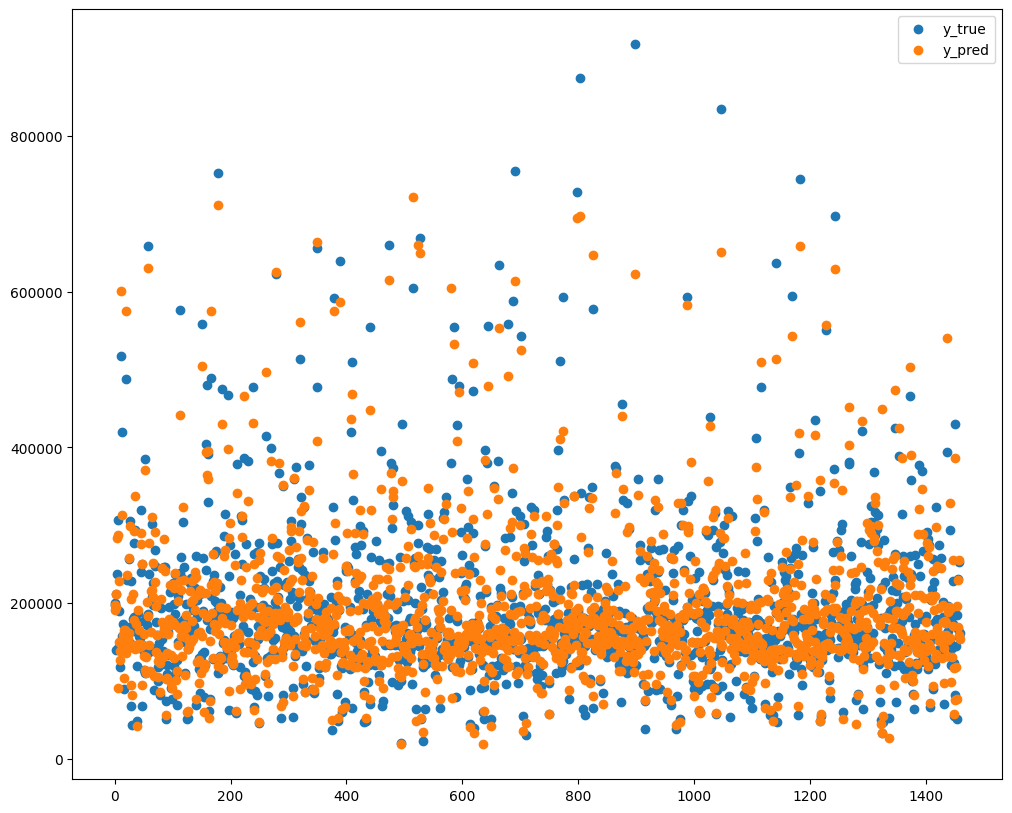

In [21]:
plt.scatter(range(len(y_true)), y_true, label='y_true')
plt.scatter(range(len(y_true)), y_pred, label='y_pred')
plt.legend()
plt.show()

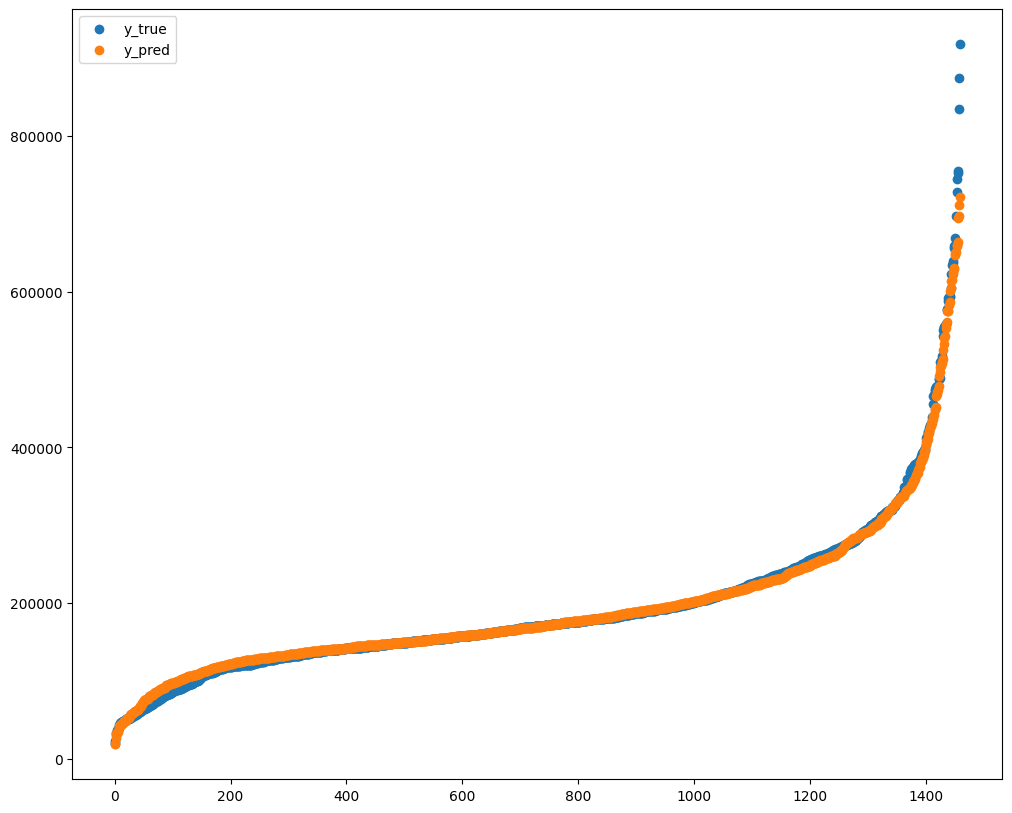

In [22]:
# another way of visualising
plt.scatter(range(len(y_true)), sorted(y_true), label='y_true')
plt.scatter(range(len(y_true)), sorted(y_pred), label='y_pred')
plt.legend()
plt.show()

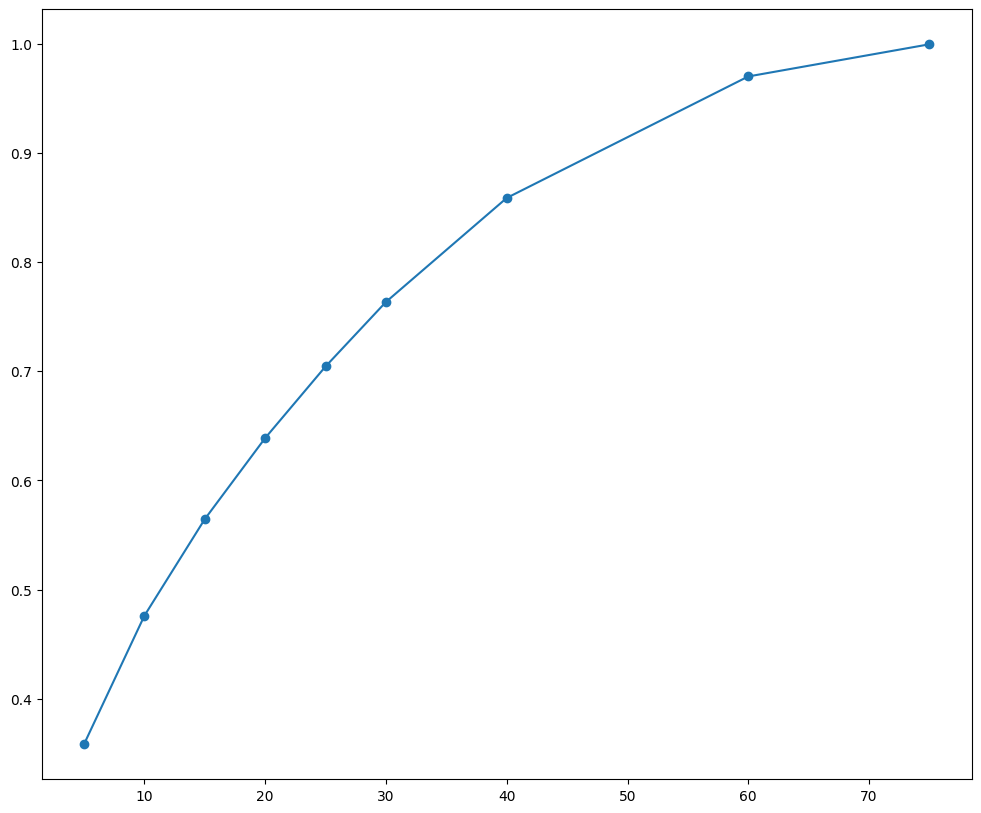

In [23]:
from sklearn.decomposition import PCA

cs = [5, 10, 15, 20, 25, 30, 40, 60, 75]
info = []
for i in cs:
  pca = PCA(n_components=i)
  pca.fit(ds_scaled[:, :-1])
  info.append(pca.explained_variance_ratio_.sum())

plt.plot(cs, info, '-o')

In [24]:
pca = PCA(n_components=40)
Xpca = pca.fit_transform(ds_scaled[:, :-1])
y = ds['SalePrice']

kf = KFold(n_splits=5)

mses = []
mapes = []
n = 0

y_true, y_pred = np.array([]), np.array([])
for train_index, test_index in kf.split(X):
    X_train, X_test = Xpca[train_index], Xpca[test_index]
    y_train, y_test = y[train_index], y[test_index]
    baseline_estimator = GradientBoostingRegressor(random_state=0)
    baseline_estimator.fit(X_train, y_train)
    y_true = np.append(y_true, y_test)
    y_pred = np.append(y_pred, baseline_estimator.predict(X_test))

print(mse(y_true, y_pred)**0.5)
print(mape(y_true, y_pred))

35956.650378010956
0.11474820338028681


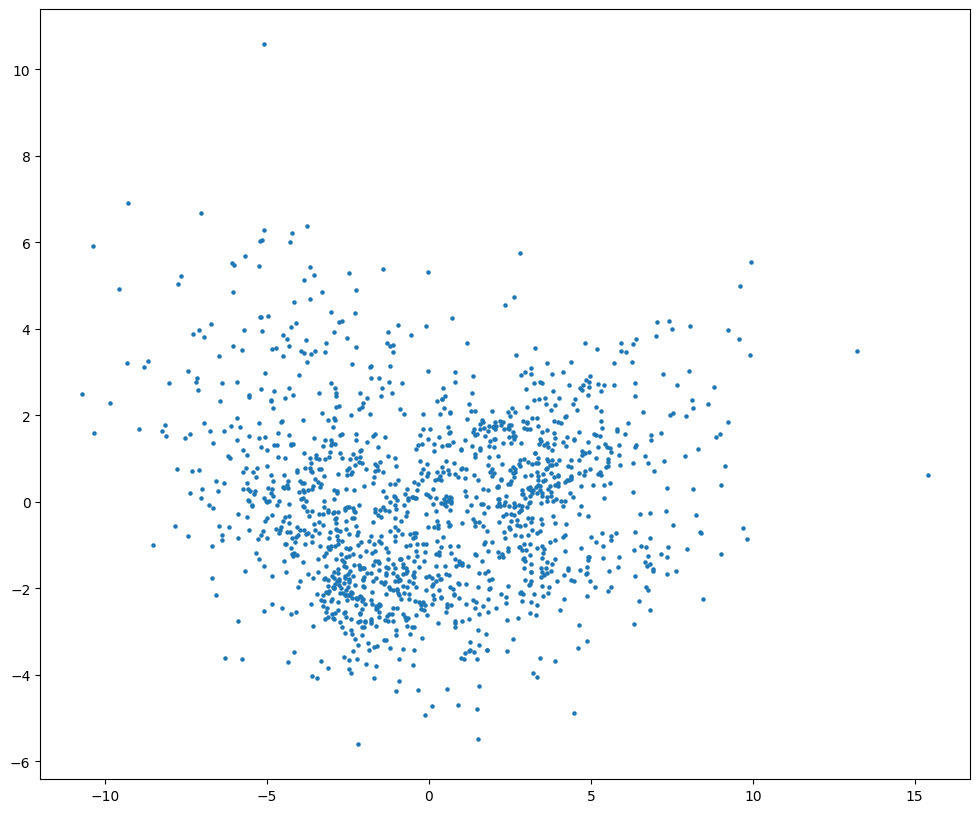

In [25]:
pca = PCA(n_components=2)
vis = pca.fit_transform(ds_scaled[:, :-1])
plt.scatter(vis[:, 0], vis[:, 1], s = 5)

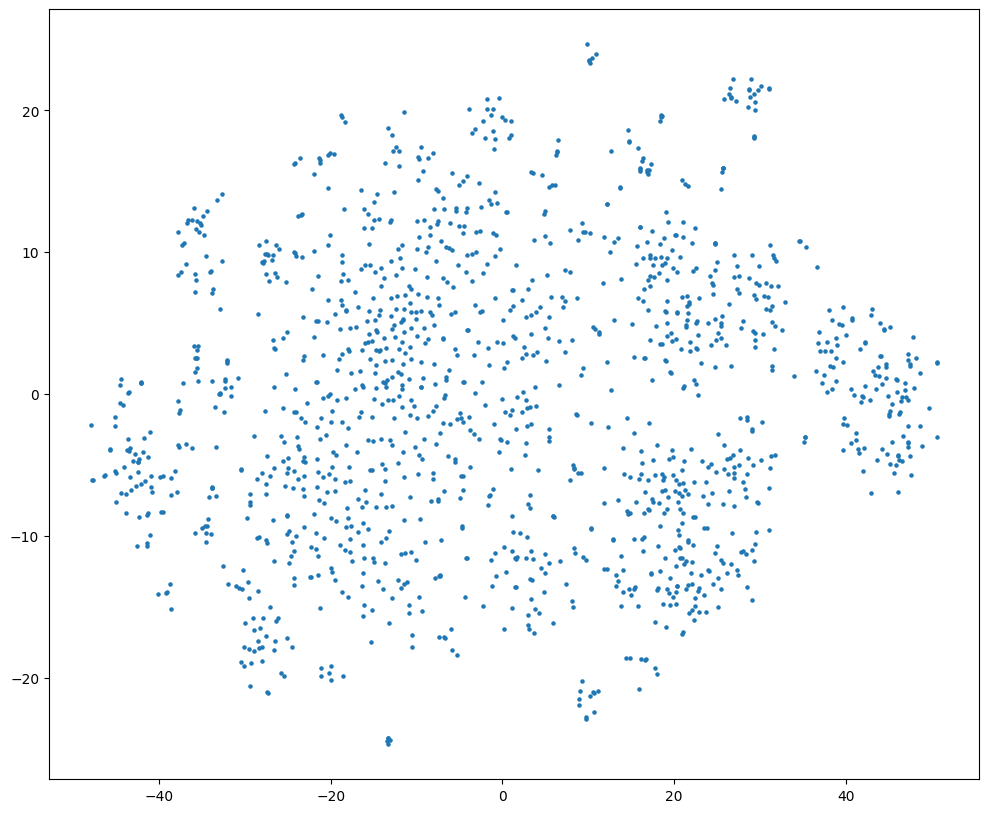

In [26]:
from sklearn.manifold import TSNE

pca = TSNE(n_components=2, perplexity=50, random_state=0)
vis = pca.fit_transform(ds_scaled[:, :-1])
plt.scatter(vis[:,0], vis[:,1], s=5)

Random sampling for TSNE

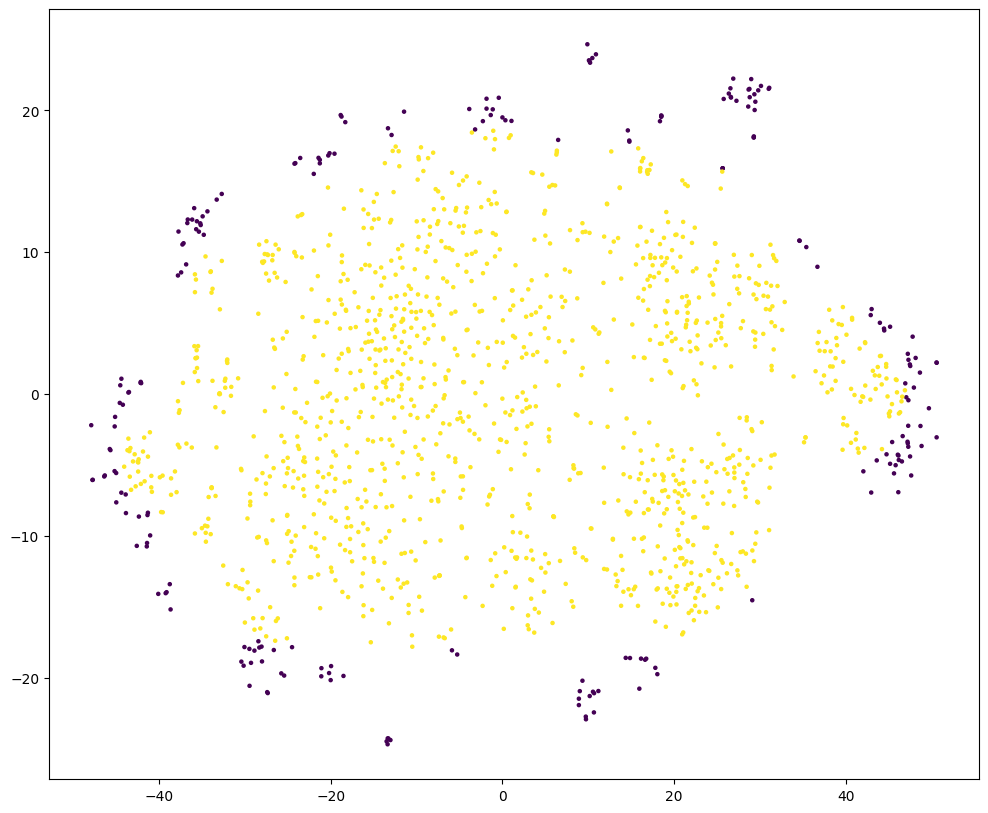

In [27]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

is_outlier = IsolationForest(contamination=0.15, random_state=0,
                            n_estimators=1000).fit_predict(vis)
plt.scatter(vis[:, 0], vis[:, 1], s=5, c=is_outlier)
plt.show()

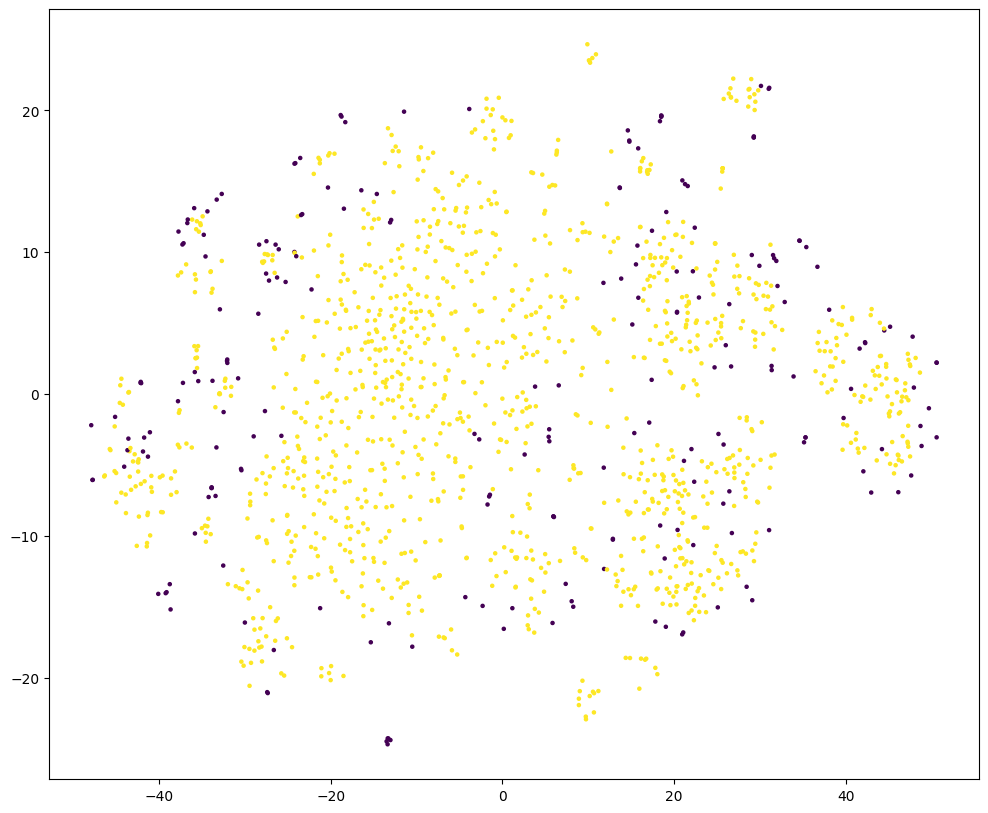

In [28]:
is_outlier = LocalOutlierFactor(contamination=0.15, n_neighbors=5).fit_predict(vis)
plt.scatter(vis[:, 0], vis[:, 1], s=5, c=is_outlier)
plt.show()


# How can we use Clusters? for finding different chunks of people?

* What are different ways, in which we can use this? we can use clustered data?

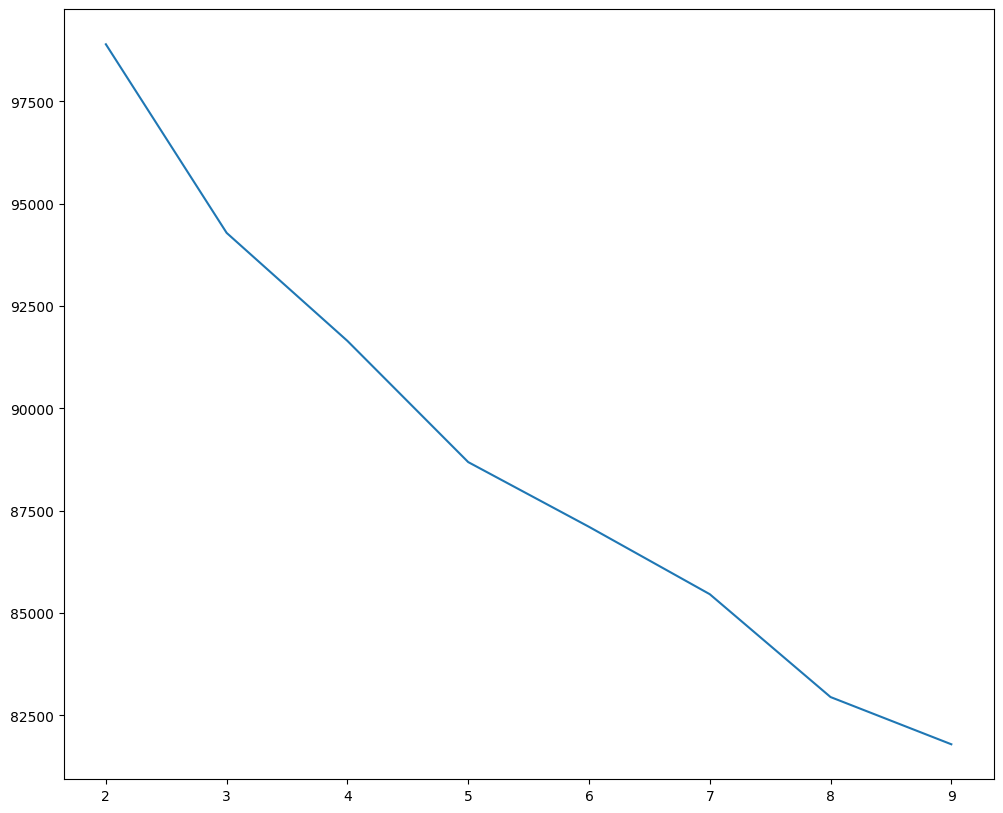

In [29]:
from sklearn.cluster import KMeans

elbow = []
for k in range(2,10):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(ds_scaled[:, :-1])
  elbow.append(kmeans.inertia_)

plt.plot(range(2,10), elbow)

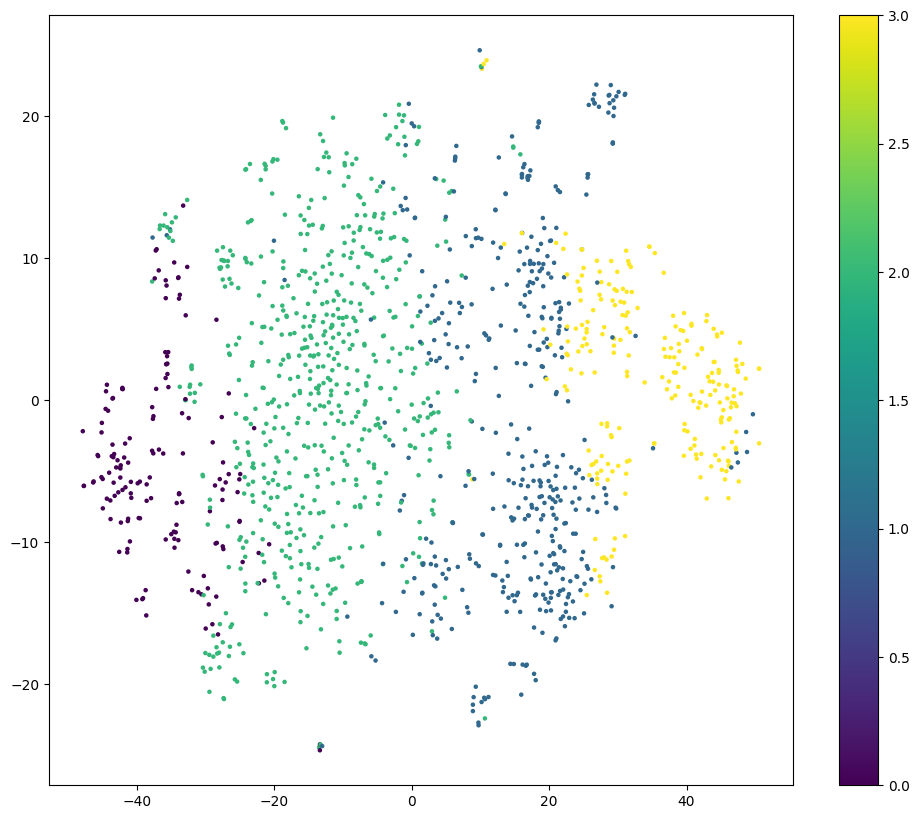

In [30]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(ds_scaled[:, :-1])
plt.scatter(vis[:, 0], vis[:, 1], s=5, c=kmeans.labels_)
plt.colorbar()